1. Defining hyperparameters.

In [1]:
config = {
    #Reproducibility and data.
    "data": {
        "raw_path": "raw/Stars.csv",         
        "test_size": 0.2, #20% of data for testing.               
        "random_state": 42, #Seed fixation for reproducibility.            
        "target_col": "Type", #Target variable.                
        "missing_threshold": 0.5, #Discard columns with more than 50% missing values.     
        "imputation_strategy": "mean" #Filling technique.  
    },

    #Feature selection configuration.
    "feature_selection": {
        "top_k": 7, #Number of features selected after ranking.          
        "weights": {
            "pearson": 0.3, #Weight assigned to Pearson correlation score.     
            "mutual_info": 0.3, #Weight assigned to Mutual Information score.     
            "random_forest": 0.4 #Weight assigned to Random Forest importance score.     
        }
    },

    #MLP architecture.
    "model": {
        "hidden_sizes": [32, 16], #Two hidden layers: the firs with 32 neurons, and the second with 16.      
        "dropout": 0.2, #Random shutdown of 20% of neurons.               
        "learning_rate": 0.001, #How much the model weights change in response to the estimated error with each update.       
        "batch_size": 32, #Processing 32 samples at a time before updating their internal weights.              
        "epochs": 100, #Maximum limit of 100 complete passes through the dataset during training.                 
        "early_stopping_patience": 10 #Discontinue training if the loss of validation does not improve for 10 consecutive seasons.  
    }
}

2. Defining seed.

In [2]:
import wandb
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn. preprocessing import StandardScaler
from sklearn. impute import SimpleImputer
from scipy.stats import ks_2samp, chi2_contingency
import yaml, random, matplotlib.pyplot as plt
import kagglehub, shutil, os

#Set a global seed to ensure reproducibility of experiments.
def set_seed(seed=42):
    #Set seed for Python's built-in random module.
    random.seed (seed)
    #Set seed for NumPy operations.
    np.random.seed(seed)
    #Set seed for PyTorch (CPU).
    torch.manual_seed(seed)
    #If GPU is available, set seed for CUDA as well.
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

3. Saving data as a wandb artifact.

In [3]:
df_raw = pd.read_csv("../dataset/raw/Stars.csv") #Reading data.

In [4]:
import wandb

#Initialize a W&B run.
wandb.init(
    project="mlops-star-type",
    job_type="load_raw",   #Defines the pipeline step.
    name="load_raw"        #Name of the run.
)

#Create a dataset artifact.
artifact = wandb.Artifact(
    name="raw_data", 
    type="dataset", 
    description="Star type classification raw dataset from Kaggle"
)

#Save DataFrame temporarily. 
temp_path = "temp_raw.csv"

#Export raw DataFrame to CSV.
df_raw.to_csv(temp_path, index=False)

#Add file to artifact.
artifact.add_file(temp_path)

#Log artifact to W&B.
wandb.log_artifact(artifact)

#Log metadata to W&B dashboard.
wandb.summary["rows"] = len(df_raw)                #Number of rows.
wandb.summary["columns"] = list(df_raw.columns)   #Column names.

#Finish run.
wandb.finish()

print("Raw data artifact saved to W&B.")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Cliente\_netrc.
wandb: Currently logged in as: geovanafreitas (geovanafreitas-ufrn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


rows,240


Raw data artifact saved to W&B.


4. Cleaning data


In [5]:
#Remove duplicate rows from a DataFrame.
def remove_duplicates(df:pd.DataFrame)->pd.DataFrame:
    #Store initial number of rows.
    before = len(df)
    
    #Remove duplicate rows.
    df = df.drop_duplicates()

    #Calculate how many rows were removed.
    removed = before - len(df)

    #Print summary of the operation.
    print(
        f"Removed {removed} duplicate rows "
        f"({removed / before:.1%} of dataset)"
    )

    #Logs how many rows were removed and their proportion relative to the original dataset.
    return df


#Apply function to raw dataset.
df_clean = remove_duplicates(df_raw)

Removed 0 duplicate rows (0.0% of dataset)


In [6]:
#Normalize text in the Color column.
df_clean['Color']=df_clean['Color'].str.lower().str.strip()

#Standardize similar color categories.
df_clean['Color']=df_clean['Color'].replace({
    'yellow-white':'white-yellow',
    'yellowish white':'white-yellow',
    'blue white':'blue-white',
    'whitish':'white'
})

#Apply one-hot encoding to categorical variables.
df_clean=pd.get_dummies(
    df_clean,
    columns=['Color','Spectral_Class'],
    drop_first=True
)

print(f"New columns after encoding: {df_clean.columns.tolist()}")

New columns after encoding: ['Temperature', 'L', 'R', 'A_M', 'Type', 'Color_blue-white', 'Color_orange', 'Color_orange-red', 'Color_pale yellow orange', 'Color_red', 'Color_white', 'Color_white-yellow', 'Color_yellowish', 'Spectral_Class_B', 'Spectral_Class_F', 'Spectral_Class_G', 'Spectral_Class_K', 'Spectral_Class_M', 'Spectral_Class_O']


In [7]:
def handle_missing_values(df:pd.DataFrame,
    strategy:str="mean",
    threshold:float=0.5)->pd.DataFrame:

    #Compute the proportion of missing values per column.
    missing_fraction=df.isnull().mean()

    #Select columns above the missing threshold.
    cols_to_drop=missing_fraction[
        missing_fraction>threshold
    ].index.tolist()

    #Drop columns with too many missing values.
    df=df.drop(columns=cols_to_drop)

    #Log removed columns.
    print(f"Dropped {len(cols_to_drop)} columns (>{threshold:.0%} missing)")

    #Select numeric columns for imputation.
    numeric_cols=df.select_dtypes(include=[np.number]).columns

    #Create imputer with defined strategy.
    imputer=SimpleImputer(strategy=strategy)

    #Apply imputation to numeric columns.
    df[numeric_cols]=imputer.fit_transform(df[numeric_cols])

    #Select categorical columns.
    cat_cols=df.select_dtypes(include=["object"]).columns

    #Fill missing values in categorical columns.
    df[cat_cols]=df[cat_cols].fillna("missing")

    #Return cleaned dataset.
    return df


#Apply cleaning pipeline to dataset.
df_clean=handle_missing_values(
    df_clean,
    strategy=config["data"]["imputation_strategy"],
    threshold=config["data"]["missing_threshold"]
)

#Log final dataset shape.
print(f"Clean dataset: {len(df_clean)} rows, {df_clean.shape[1]} columns")

Dropped 0 columns (>50% missing)
Clean dataset: 240 rows, 19 columns


In [8]:
#Initialize Weights and Biases run.
wandb.init(
    project="mlops-star-type",
    job_type="clean_data",
    name="clean_data"
)

#Create dataset artifact for cleaned data.
artifact=wandb.Artifact(
    "clean_data",
    type="dataset",
    description="Star type classification after deduplication and imputation."
)

#Save cleaned dataset to temporary file.
temp_path="temp_clean.csv"
df_clean.to_csv(temp_path,index=False)

#Add file to artifact.
artifact.add_file(temp_path)

#Log artifact to W&B.
wandb.log_artifact(artifact)

#Store dataset metadata.
wandb.summary["rows"]=len(df_clean)
wandb.summary["columns"]=df_clean.shape[1]

wandb.finish()

columns,19
rows,240


5. Testing clean data

In [9]:
def test_no_missing_values(df:pd.DataFrame)->None:

    #Calculate total missing values in dataset.
    total_missing=df.isnull().sum().sum()

    #Assert that no missing values remain.
    assert total_missing==0, f"TEST FAILED: {total_missing} missing values remain."

    print("PASS: no missing values.")


def test_target_values(df:pd.DataFrame,
    target_col:str,
    allowed_values)->None:

    #Identify invalid target values.
    invalid_mask=~df[target_col].isin(allowed_values)
    invalid_count=invalid_mask.sum()

    #Assert target column contains only valid values.
    assert invalid_count==0, (
        f"TEST FAILED: {invalid_count} unexpected values in '{target_col}': "
        f"{df.loc[invalid_mask, target_col].unique()}"
    )

    print(f"PASS: '{target_col}' contains only valid values.")


#Run consistency test for missing values.
test_no_missing_values(df_clean)

print("All consistency tests passed.")

PASS: no missing values.
All consistency tests passed.


In [10]:
def test_range_checks(df):

    #Check if target variable is within valid range.
    assert df['Type'].between(0,5).all(), "Error: 'Type' out of range [0,5]."

    #Check if temperature values are strictly positive.
    assert (df['Temperature']>0).all(), "Error: negative or zero temperature detected."


#Run range validation tests.
test_range_checks(df_clean)

print("PASS: values are within expected ranges.")

PASS: values are within expected ranges.


6. Spliting data.


In [11]:
from sklearn.model_selection import train_test_split
import pandas as pd

def split_train_test(df:pd.DataFrame,
    target_col:str,
    test_size:float=0.2,
    random_state:int=42):

    #Split features and target variable.
    X=df.drop(columns=[target_col])
    y=df[target_col]

    #Perform stratified train-test split.
    X_train,X_test,y_train,y_test=train_test_split(
        X,y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    #Recombine features and target for train set.
    train_df=pd.concat([X_train,y_train],axis=1)

    #Recombine features and target for test set.
    test_df=pd.concat([X_test,y_test],axis=1)

    return train_df,test_df


#Apply train-test split on cleaned dataset.
train_df,test_df=split_train_test(
    df_clean,
    target_col=config["data"]["target_col"],
    test_size=config["data"]["test_size"],
    random_state=config["data"]["random_state"]
)

print(f"Training set: {len(train_df):,} rows.")
print(f"Test set: {len(test_df):,} rows.")

Training set: 192 rows.
Test set: 48 rows.


In [12]:
import os
import pandas as pd

#List files in the current directory.
print("Files in directory:", os.listdir())

#Retrieve target variable from configuration.
target = config["data"]["target_col"]

#Check if training file exists.
if not os.path.exists("train.csv"):
    raise FileNotFoundError("train.csv not found in current directory")

#Load dataset.
train_df = pd.read_csv("train.csv")

#Display dataset columns.
print("\nDataset columns:")
print(train_df.columns.tolist())

#Check if target column exists.
if target not in train_df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset")

#Split features and target variable.
X_train = pd.get_dummies(train_df.drop(columns=[target]))
y_train = train_df[target]

#Display shapes of feature matrix and target vector.
print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

Files in directory: ['best_model.pt', 'jupyter notebook ia.ipynb', 'tea_debug.log', 'temp_clean.csv', 'temp_raw.csv', 'temp_test_data.csv', 'temp_train_data.csv', 'train.csv', 'wandb']

Dataset columns:
['Temperature', 'L', 'R', 'A_M', 'Color_blue-white', 'Color_orange', 'Color_orange-red', 'Color_pale yellow orange', 'Color_red', 'Color_white', 'Color_white-yellow', 'Color_yellowish', 'Spectral_Class_B', 'Spectral_Class_F', 'Spectral_Class_G', 'Spectral_Class_K', 'Spectral_Class_M', 'Spectral_Class_O', 'Type']

Shapes:
X_train: (192, 18)
y_train: (192,)


7. Selecting features.

In [13]:
import pandas as pd
import numpy as np

from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

In [14]:
#Compute the correlation of each feature in X_train with the target y_train.
#corrwith is suitable when features (X) and target (y) are already separated.
corr_scores = X_train.corrwith(y_train)

#Define the selection threshold for feature filtering.
#A common choice is 0.5 to capture moderate to strong correlations.
threshold = 0.5
selected_features_pearson = corr_scores[abs(corr_scores) > threshold].index.tolist()

#Create a DataFrame to organize feature names and their correlation scores.
pearson_df = pd.DataFrame({
    "feature": X_train.columns,
    "pearson_score": corr_scores.values
}).sort_values(by="pearson_score", ascending=False)

#Print the list of selected features based on the defined threshold.
print("Selected features (Pearson > 0.5):", selected_features_pearson)

#Display the top features ranked by Pearson correlation.
display(pearson_df.head(10))

Selected features (Pearson > 0.5): ['L', 'R', 'A_M']


,feature,pearson_score
1,L,0.667626
2,R,0.661564
0,Temperature,0.382290
17,Spectral_Class_O,0.370470
4,Color_blue-white,0.140523
5,Color_orange,0.105920
14,Spectral_Class_G,0.105920
12,Spectral_Class_B,0.101575
15,Spectral_Class_K,0.036886
10,Color_white-yellow,0.032807


In [15]:
#Compute Mutual Information (MI) scores.
mi_scores = mutual_info_classif(df_clean.drop(columns=['Type']), df_clean['Type'], random_state=42)

#Create a Series to visualize the results.
mi_df = pd.Series(mi_scores, index=df_clean.drop(columns=['Type']).columns).sort_values(ascending=False)

print("Mutual Information Scores:")
print(mi_df)

#You can select the top-k features, for example, the top 5.
top_k_mi = mi_df.head(5).index.tolist()
print("\nTop 5 features (MI):", top_k_mi)

Mutual Information Scores:
R                           1.728057
A_M                         1.576546
L                           1.092197
Temperature                 0.638725
Color_red                   0.508330
Spectral_Class_M            0.456918
Spectral_Class_O            0.227174
Spectral_Class_B            0.169707
Spectral_Class_F            0.109322
Color_blue-white            0.095734
Color_orange                0.064531
Color_white                 0.047302
Spectral_Class_K            0.014319
Color_pale yellow orange    0.012959
Color_white-yellow          0.000292
Color_orange-red            0.000000
Color_yellowish             0.000000
Spectral_Class_G            0.000000
dtype: float64

Top 5 features (MI): ['R', 'A_M', 'L', 'Temperature', 'Color_red']


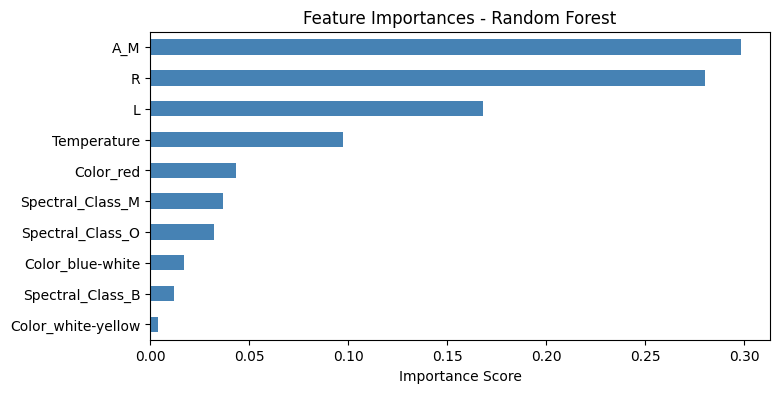

Top 10 features (Random Forest): ['A_M', 'R', 'L', 'Temperature', 'Color_red', 'Spectral_Class_M', 'Spectral_Class_O', 'Color_blue-white', 'Spectral_Class_B', 'Color_white-yellow']


In [16]:
#Train the Random Forest model.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(df_clean.drop(columns=['Type']), df_clean['Type'])

#Extract feature importances.
importances = pd.Series(rf.feature_importances_, index=df_clean.drop(columns=['Type']).columns)
importances = importances.sort_values(ascending=False)

#Plot feature importances for visual analysis.
plt.figure(figsize=(8, 4))
importances.head(10).plot(kind='barh', color='steelblue')
plt.title('Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()  #Put the most important feature on top
plt.show()

#Select the top 10 features.
top10_rf = importances.nlargest(10).index.tolist()
print("Top 10 features (Random Forest):", top10_rf)

In [17]:
#Prepare Mutual Information (MI) results.
#reset_index converts the feature names from the index into a regular column.
mi_df_final = mi_df.reset_index()
mi_df_final.columns = ['feature', 'mi_score']

#Use the previously computed Random Forest feature importances.
#reset_index is used to convert the Series into a DataFrame format.
rf_df_final = importances.reset_index()
rf_df_final.columns = ['feature', 'rf_score']

#Merge the three feature importance methods into a single DataFrame.
#This aligns features that exist across all methods.
feat_df = pearson_df.merge(mi_df_final, on="feature").merge(rf_df_final, on="feature")

#Apply Min-Max normalization to make all scores comparable across different scales.
#This ensures no method dominates due to scale differences.
for col in ["pearson_score", "mi_score", "rf_score"]:

    #Use absolute values for Pearson to focus on relationship strength, not direction.
    if col == "pearson_score":
        feat_df[col] = feat_df[col].abs()
        
    #Apply Min-Max scaling: (x - min) / (max - min)
    feat_df[col] = (feat_df[col] - feat_df[col].min()) / (feat_df[col].max() - feat_df[col].min())

#Compute the final feature importance score as the average of all methods.
#This combines linear (Pearson), non-linear (MI), and model-based (RF) perspectives.
feat_df['final_score'] = feat_df[["pearson_score", "mi_score", "rf_score"]].mean(axis=1)

#Sort features by final importance score in descending order.
feat_df = feat_df.sort_values(by="final_score", ascending=False)

print("Consolidated Feature Importance Table:")
display(feat_df)

Consolidated Feature Importance Table:


,feature,pearson_score,mi_score,rf_score,final_score
17,A_M,1.000000,0.912323,1.000000,0.970774
1,R,0.692590,1.000000,0.939625,0.877405
0,L,0.698936,0.632038,0.564353,0.631776
2,Temperature,0.400219,0.369620,0.326314,0.365384
15,Color_red,0.421804,0.294163,0.145735,0.287234
16,Spectral_Class_M,0.421804,0.264412,0.123301,0.269839
3,Spectral_Class_O,0.387844,0.131462,0.107392,0.208900
4,Color_blue-white,0.147113,0.055400,0.057772,0.086762
7,Spectral_Class_B,0.106339,0.098207,0.040916,0.081820
5,Color_orange,0.110888,0.037343,0.001496,0.049909


In [18]:
#Retrieve number of top features to select from configuration.
top_k = config.get("feature_selection", {}).get("top_k", 7)

#Select top features based on final ranking.
selected_features = feat_df["feature"].head(top_k).tolist()

#Apply feature selection to datasets.
train_df = train_df[selected_features + [target]]
test_df = test_df[selected_features + [target]]

selected_features

['A_M',
 'R',
 'L',
 'Temperature',
 'Color_red',
 'Spectral_Class_M',
 'Spectral_Class_O']

8. Statistical analysis.

In [19]:
from scipy.stats import ks_2samp, chi2_contingency

def compare_distributions(train_df:pd.DataFrame,
    test_df:pd.DataFrame,
    columns:list)->dict:

    #Store statistical test results for each feature.
    results={}

    for col in columns:

        #Remove missing values from both datasets.
        train_vals=train_df[col].dropna()
        test_vals=test_df[col].dropna()

        #Continuous features: use Kolmogorov-Smirnov test.
        if train_df[col].dtype in ["int64","float64"]:

            stat,p=ks_2samp(train_vals,test_vals)

            results[col]={
                "test":"KS",
                "statistic":stat,
                "p_value":p
            }

        #Categorical features: use Chi² test.
        else:

            train_counts=train_vals.value_counts(normalize=True)
            test_counts=test_vals.value_counts(normalize=True)

            all_cats=sorted(
                set(train_counts.index).union(test_counts.index)
            )

            train_probs=[train_counts.get(c,0) for c in all_cats]
            test_probs=[test_counts.get(c,0) for c in all_cats]

            chi2,p,_,_=chi2_contingency(
                [train_probs,test_probs]
            )

            results[col]={
                "test":"Chi2",
                "statistic":chi2,
                "p_value":p
            }

    return results


#Define feature columns excluding target variable.
feature_cols=[
    c for c in train_df.columns
    if c!=config["data"]["target_col"]
]

#Run distribution comparison between train and test sets.
comp_results=compare_distributions(train_df,test_df,feature_cols)

In [20]:
import wandb
import pandas as pd

#Initialize W&B run for data split tracking.
wandb.init(
    project="mlops-star-type",
    job_type="split_data",
    name="split_data"
)

#Save train and test splits as separate artifacts.
for split_name, split_df in [("train_data", train_df),
                             ("test_data", test_df)]:

    #Define temporary file path.
    path=f"temp_{split_name}.csv"

    #Save dataframe to CSV.
    split_df.to_csv(path,index=False)

    #Create W&B artifact.
    art=wandb.Artifact(split_name,type="dataset")

    #Attach file to artifact.
    art.add_file(path)

    #Log artifact to W&B.
    wandb.log_artifact(art)

#Convert distribution comparison results into table format.
comp_df=pd.DataFrame(comp_results).T.reset_index()

#Rename columns for clarity.
comp_df.columns=["feature","test","statistic","p_value"]

#Create W&B table.
comp_table=wandb.Table(dataframe=comp_df)

#Log distribution comparison table.
wandb.log({"distribution_comparison":comp_table})

#Store dataset sizes in summary.
wandb.summary["train_size"]=len(train_df)
wandb.summary["test_size"]=len(test_df)

wandb.finish()

print("Train and test artifacts saved.")

test_size,48
train_size,192


Train and test artifacts saved.


9. Neural Network Foundations and
PyTorch.

In [21]:
import torch

#Create a 1D tensor (list)
x=torch.tensor([1.0,2.0,3.0])

#Create a 2D tensor (matrix).
A=torch.tensor([
    [1.0,2.0],
    [3.0,4.0]
])

#Print tensor shapes.
print(x.shape)
print(A.shape)

#Print tensor data type.
print(A.dtype)

#Initialize random weight matrix.
W=torch.randn(64,32)

#Initialize bias vector with zeros.
b=torch.zeros(32)

#Select device (GPU if available, otherwise CPU).
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Move tensor to selected device.
W=W.to(device)

torch.Size([3])
torch.Size([2, 2])
torch.float32


In [22]:
import torch
import torch.nn as nn

#Define a simple neural network layer.
class SimpleLayer(nn.Module):

    def __init__(self,in_features:int,out_features:int):

        #Initialize parent class.
        super().__init__()

        #Linear transformation layer.
        self.linear=nn.Linear(in_features,out_features)

        #Activation function.
        self.relu=nn.ReLU()

    def forward(self,x:torch.Tensor)->torch.Tensor:

        #Apply linear transformation.
        z=self.linear(x)

        #Apply ReLU activation.
        a=self.relu(z)

        return a


#Instantiate layer.
layer=SimpleLayer(10,5)

for name,param in layer.named_parameters():
    print(f"{name}:{param.shape}")

linear.weight:torch.Size([5, 10])
linear.bias:torch.Size([5])


In [23]:
import torch.nn as nn

#Define a simple feedforward neural network.
model=nn.Sequential(

    #First linear layer.
    nn.Linear(10,64),

    #Activation function.
    nn.ReLU(),

    #Regularization to reduce overfitting.
    nn.Dropout(0.2),

    #Second linear layer.
    nn.Linear(64,32),

    #Activation function.
    nn.ReLU(),

    #Regularization to reduce overfitting.
    nn.Dropout(0.2),

    #Output layer.
    nn.Linear(32,1),
)

print(model)

Sequential(
  (0): Linear(in_features=10, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=1, bias=True)
)


In [24]:
import torch
from torch.utils.data import TensorDataset, DataLoader

#Create synthetic feature data.
X=torch.randn(1000,5)

#Create binary target labels.
y=torch.randint(0,2,(1000,1)).float()

#Combine features and target into a dataset.
dataset=TensorDataset(X,y)

#Create data loader for batching and shuffling.
loader=DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

#Iterate over one batch to check shapes.
for X_batch,y_batch in loader:
    print(X_batch.shape,y_batch.shape)
    break

torch.Size([32, 5]) torch.Size([32, 1])


10. Building MLP architeture.

In [25]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset,DataLoader
import numpy as np
import torch

#Prepare PyTorch dataloaders from pandas DataFrames.
def prepare_dataloaders(train_df,test_df,
                        target_col:str,
                        batch_size:int):

    #Extract training features and labels.
    X_train=train_df.drop(columns=[target_col]).values.astype(np.float32)
    y_train=train_df[target_col].values.astype(np.float32).reshape(-1,1)

    #Extract test features and labels.
    X_test=test_df.drop(columns=[target_col]).values.astype(np.float32)
    y_test=test_df[target_col].values.astype(np.float32).reshape(-1,1)

    #Standardize features using training data statistics.
    scaler=StandardScaler()
    X_train=scaler.fit_transform(X_train)
    X_test=scaler.transform(X_test)

    #Convert arrays to PyTorch tensors.
    train_ds=TensorDataset(
        torch.tensor(X_train),
        torch.tensor(y_train)
    )

    test_ds=TensorDataset(
        torch.tensor(X_test),
        torch.tensor(y_test)
    )

    #Create data loaders for batching.
    train_loader=DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader=DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader,test_loader,scaler

In [26]:
import torch
import torch.nn as nn

#Define a flexible multi-layer perceptron model.
class MLP(nn.Module):

    def __init__(self,
                input_dim:int,
                hidden_sizes:list,
                output_dim:int=1,
                dropout:float=0.2):

        #Initialize parent class.
        super().__init__()

        #List to store network layers.
        layers=[]

        #Track input size for each layer.
        prev_size=input_dim

        #Build hidden layers dynamically.
        for hidden_size in hidden_sizes:

            layers.append(nn.Linear(prev_size,hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout))

            prev_size=hidden_size

        #Output layer.
        layers.append(nn.Linear(prev_size,output_dim))

        #Create sequential model.
        self.net=nn.Sequential(*layers)

    def forward(self,x:torch.Tensor)->torch.Tensor:

        #Forward pass through network.
        return self.net(x)


#Instantiate model.
model=MLP(
    input_dim=30,
    hidden_sizes=[64,32],
    dropout=0.2
)

#Print model architecture.
print(model)

#Compute total number of parameters.
total_params=sum(p.numel() for p in model.parameters())

print(f"Total parameters:{total_params:,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters:4,097


11. Training model.

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import wandb

#Train MLP model with W&B logging and early stopping.
def train_model(config,train_loader,test_loader,input_dim):

    #Select device (GPU if available).
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

    #Initialize model.
    model=MLP(
        input_dim=input_dim,
        hidden_sizes=config["model"]["hidden_sizes"],
        dropout=config["model"]["dropout"],
        output_dim=6
    ).to(device)

    #Define loss function for multiclass classification.
    criterion=nn.CrossEntropyLoss()

    #Define optimizer.
    optimizer=optim.Adam(
        model.parameters(),
        lr=config["model"]["learning_rate"]
    )

    #Track model in W&B.
    wandb.watch(model,log="all",log_freq=10)

    #Early stopping setup.
    best_val_loss=float("inf")
    patience=config["model"]["early_stopping_patience"]
    patience_counter=0

    #Training loop.
    for epoch in range(config["model"]["epochs"]):

        #Training phase.
        model.train()
        train_loss=0.0

        for X_batch,y_batch in train_loader:

            X_batch=X_batch.to(device)
            y_batch=y_batch.to(device).long().squeeze()

            optimizer.zero_grad()

            output=model(X_batch)
            loss=criterion(output,y_batch)

            loss.backward()
            optimizer.step()

            train_loss+=loss.item()*X_batch.size(0)

        train_loss/=len(train_loader.dataset)

        #Validation phase.
        model.eval()
        val_loss=0.0
        correct=0

        with torch.no_grad():

            for X_batch,y_batch in test_loader:

                X_batch=X_batch.to(device)
                y_batch=y_batch.to(device).long().squeeze()

                output=model(X_batch)
                loss=criterion(output,y_batch)

                val_loss+=loss.item()*X_batch.size(0)

                preds=torch.argmax(output,dim=1)
                correct+=(preds==y_batch).sum().item()

        val_loss/=len(test_loader.dataset)
        val_acc=correct/len(test_loader.dataset)

        #Log metrics to W&B.
        wandb.log({
            "epoch":epoch,
            "train_loss":train_loss,
            "val_loss":val_loss,
            "val_acc":val_acc
        })

        #Early stopping check.
        if val_loss<best_val_loss:

            best_val_loss=val_loss
            patience_counter=0

            torch.save(model.state_dict(),"best_model.pt")

            model_artifact=wandb.Artifact(
                "trained_model",
                type="model",
                description=f"MLP checkpoint at epoch {epoch}"
            )

            model_artifact.add_file("best_model.pt")
            wandb.log_artifact(model_artifact)

        else:

            patience_counter+=1

            if patience_counter>=patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load("best_model.pt"))

    return model

In [28]:
#Initialize W&B run for training tracking.
wandb.init(
    project="mlops-star-type",
    job_type="train",
    name="mlp_training",
    config=config
)

#Load train and test datasets.
train_df=pd.read_csv("temp_train_data.csv")
test_df=pd.read_csv("temp_test_data.csv")

#Prepare dataloaders and scaler.
train_loader,test_loader,scaler=prepare_dataloaders(
    train_df,
    test_df,
    target_col=config["data"]["target_col"],
    batch_size=config["model"]["batch_size"]
)

#Get input feature dimension.
input_dim=train_loader.dataset.tensors[0].shape[1]

#Log input dimension.
print(f"Input dimension:{input_dim} features")

#Train model.
model=train_model(
    config,
    train_loader,
    test_loader,
    input_dim
)

wandb.finish()

print("Training complete. Best model saved to W&B.")

Input dimension:7 features


wandb: WARNING Artifact "trained_model" already exists with the same content. No new version will be created.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
train_loss,██▇▇▇▆▅▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▇▆▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██▇█████▇
val_loss,███▇▇▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,99
train_loss,0.1998
val_acc,0.91667
val_loss,0.1846


Training complete. Best model saved to W&B.


12. Viewing results.

[[8 0 0 0 0 0]
 [2 6 0 0 0 0]
 [0 0 8 0 0 0]
 [0 0 0 7 1 0]
 [0 0 0 1 7 0]
 [0 0 0 0 0 8]]


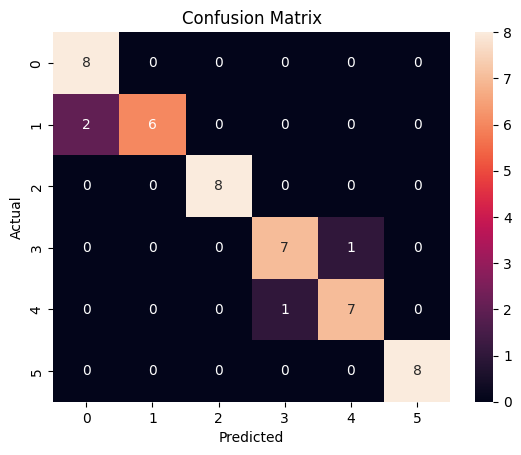

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

#Set model to evaluation mode.
model.eval()

#Store predictions and true labels.
all_preds=[]
all_labels=[]

#Disable gradient computation.
with torch.no_grad():

    for X_batch,y_batch in test_loader:

        X_batch=X_batch.to(device)

        #Forward pass.
        outputs=model(X_batch)

        #Get predicted class.
        preds=torch.argmax(outputs,dim=1).cpu().numpy()

        #Store predictions and labels.
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

#Compute confusion matrix.
cm=confusion_matrix(all_labels,all_preds)

#Print raw matrix.
print(cm)

#Plot confusion matrix.
plt.figure()
sns.heatmap(cm,annot=True,fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [30]:
#Compute correlation matrix using only numeric features.
corr=train_df.corr(numeric_only=True)

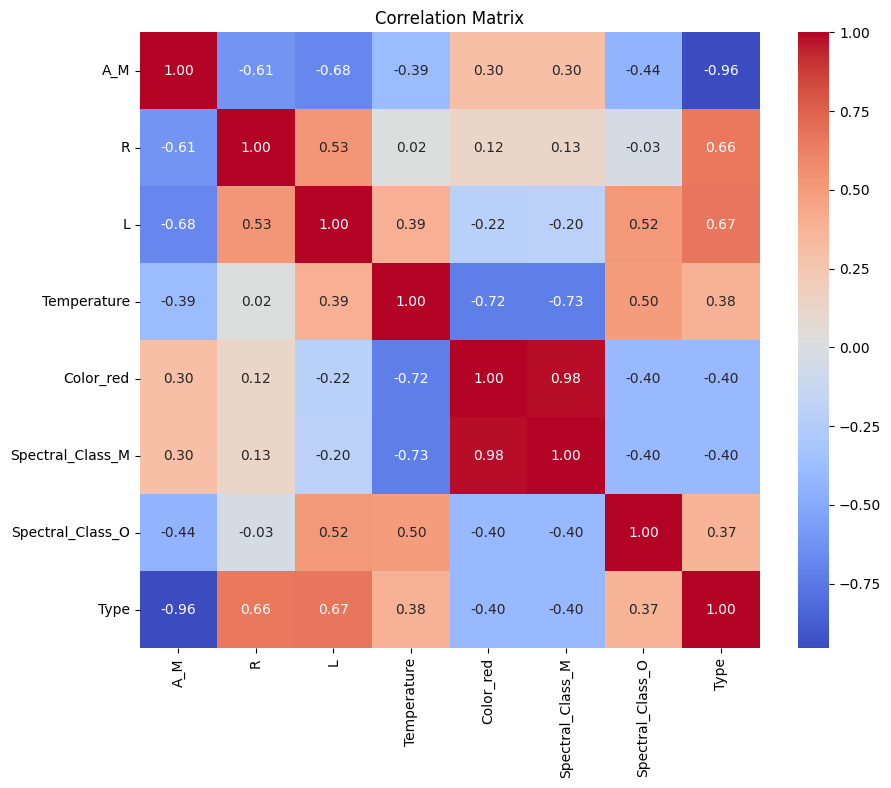

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

#Plot correlation heatmap.
plt.figure(figsize=(10,8))

sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

In [32]:
#Compute correlation matrix using only numeric features.
corr=train_df.corr(numeric_only=True)

13. Complete final pipeline.

In [33]:
#Apply one-hot encoding to categorical features.
train_df=pd.get_dummies(train_df)
test_df=pd.get_dummies(test_df)

#Align train and test sets to ensure same feature columns.
train_df,test_df=train_df.align(test_df,join="left",axis=1,fill_value=0)

In [34]:
from scipy.stats import ks_2samp, chi2_contingency
import pandas as pd
import wandb

#Compute statistical distribution differences between train and test sets.
def compare_distributions(train_df:pd.DataFrame,
                          test_df:pd.DataFrame,
                          columns:list)->dict:

    results={}

    for col in columns:

        #Remove missing values.
        train_vals=train_df[col].dropna()
        test_vals=test_df[col].dropna()

        #Numeric features: Kolmogorov-Smirnov test.
        if train_df[col].dtype in ["int64","float64"]:

            stat,p=ks_2samp(train_vals,test_vals)

            results[col]={
                "test":"KS",
                "statistic":stat,
                "p_value":p
            }

        #Categorical features: Chi-square test.
        else:

            train_counts=train_vals.value_counts(normalize=True)
            test_counts=test_vals.value_counts(normalize=True)

            all_cats=sorted(
                set(train_counts.index).union(test_counts.index)
            )

            train_probs=[train_counts.get(c,0) for c in all_cats]
            test_probs=[test_counts.get(c,0) for c in all_cats]

            chi2,p,_,_=chi2_contingency([train_probs,test_probs])

            results[col]={
                "test":"Chi2",
                "statistic":chi2,
                "p_value":p
            }

    return results


#Define feature columns excluding target variable.
feature_cols=[c for c in train_df.columns if c!=config["data"]["target_col"]]

#Run distribution comparison.
comp_results=compare_distributions(train_df,test_df,feature_cols)

#Initialize W&B run for validation tracking.
wandb.init(
    project="mlops-star-type",
    job_type="split_data",
    name="split_validation"
)

#Convert results to DataFrame.
comp_df=pd.DataFrame(comp_results).T.reset_index()

#Rename columns for clarity.
comp_df.columns=["feature","test","statistic","p_value"]

#Create W&B table.
comp_table=wandb.Table(dataframe=comp_df)

#Log results to W&B.
wandb.log({"distribution_comparison":comp_table})

#Log dataset sizes.
wandb.summary["train_size"]=len(train_df)
wandb.summary["test_size"]=len(test_df)

#Finish W&B run.
wandb.finish()

test_size,48
train_size,192
